# Test 

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from tqdm import tqdm

from wavelet_utils import loadFilterParamDict
from analysis_utils import apply_model, fit_model, smooth_stimulus_signals

Expecting to have:
* Cell database: cells_waven1.cellDB_pickle having records for each neuron 

In [29]:
#jobFolder_str=r"GBM11\g11_0409_zebra"
jobFolder_str=r"GBM11\g11_0409_zebra5"
jobFolder_str=r"GBM11\g11_0415_zebra5"
jobFolder_str=r"GBM11\g11_0423_zebra6"
jobFolder_str=r"GBM11\g11_0508_full"
#jobFolder_str=r"GBM15\g15_0408_zebra"
#jobFolder_str=r"GBM15\g15_0422_zebra3"

In [30]:
# Path definitions
data_path = "D:\\SynologyDriveSyncedDATA\\PROCESSED\\GBM\\" +  jobFolder_str + "\\ZEBRA_ANALYSIS"

temppath = r'D:\SynologyDriveSyncedDATA\PROCESSED\Waven'

lib_dim="40_26_8_5_4_2"

libpath= Path(temppath) / f'gaborLibrary_{lib_dim}.npy'
paramspath = libpath.with_suffix('.json')   

downsampled_video_path = Path(temppath) / r"zebra_s0_d420.0_fps59.94_RESAMPLED30fps_downscaled.npy"

In [31]:
# Load inputs
xs, ys, angles, sizes, freqs, phases, visual_coverage, full_screen_coverage, screen_x, screen_y = loadFilterParamDict(paramspath)

input_pickle= Path(data_path) / "cells_waven1.cellDB_pickle"
df_cells=pd.read_pickle(input_pickle)

df_cells

,cell_id,SeriesID,SNR,R_value,CNN,Accepted,Soma_Xpix,Soma_Ypix,contour,RF_indexes,...,RF_value,Azimuth,Elevation,Angle,Size,Frequency,tun_angles_fit_ori,tun_angles_fit_amplitude,tun_angles_fit_constant,tun_angles_fit_OSI
cell_id,,,,,,,,,,,,,,,,,,,,,
0,0,g11_0508_full,2.105935,0.649262,0.873005,True,37.556073,35.089188,"[[nan, nan], [40.31315740401555, 39.0], [41.0,...","[13, 13, 5, 2, 2]",...,0.166023,-59.625,1.153846,1.963495,6.480741,0.05848,1.864856,0.117149,0.050700,0.697942
1,1,g11_0508_full,3.295595,0.809126,0.983211,True,52.195856,20.982439,"[[nan, nan], [56.06804381715116, 25.0], [56.77...","[13, 17, 3, 3, 3]",...,0.222090,-59.625,10.384615,1.178097,9.525249,0.10000,1.122744,0.120285,0.047361,0.717495
2,2,g11_0508_full,2.929239,0.811503,0.866372,True,37.424075,12.235384,"[[nan, nan], [37.565077366232174, 17.0], [38.0...","[16, 19, 3, 2, 3]",...,0.156544,-52.875,15.000000,1.178097,6.480741,0.10000,1.140410,0.134908,0.017021,0.887966
3,3,g11_0508_full,2.486895,0.691701,0.876733,True,28.064144,27.166179,"[[nan, nan], [30.641018692925137, 32.0], [31.0...","[17, 14, 3, 3, 2]",...,0.189405,-50.625,3.461538,1.178097,9.525249,0.05848,1.363188,0.159002,0.012619,0.926473
4,4,g11_0508_full,1.767542,0.721091,0.884633,True,48.334584,6.944977,"[[nan, nan], [49.00745713421593, 11.0], [50.0,...","[11, 15, 3, 3, 2]",...,0.252039,-64.125,5.769231,1.178097,9.525249,0.05848,1.172874,0.196376,0.016067,0.924369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,2233,g11_0508_full,7.965590,0.957212,0.999991,True,49.254968,56.035090,"[[nan, nan], [50.78346933361591, 58.0], [51.0,...","[23, 14, 3, 4, 2]",...,0.173501,-37.125,3.461538,1.178097,14.000000,0.05848,1.324384,0.106583,0.030788,0.775875
2234,2234,g11_0508_full,5.512401,0.965151,0.999846,True,419.504521,265.640974,"[[nan, nan], [420.10515952550196, 268.0], [420...","[4, 21, 6, 4, 3]",...,0.215669,-79.875,19.615385,2.356194,14.000000,0.10000,2.472534,0.100319,0.041369,0.708025
2235,2235,g11_0508_full,2.460844,0.862587,0.992156,True,337.103997,431.401272,"[[nan, nan], [338.192998507981, 435.0], [339.0...","[6, 24, 3, 3, 3]",...,0.246377,-75.375,26.538462,1.178097,9.525249,0.10000,1.185402,0.160669,0.043941,0.785243


In [32]:
resolution = 2.14 # um/px

In [33]:
#collecting inputs

        
n_neurons = len(df_cells)
n_timepoints = len(df_cells.iloc[0]['WL_transient_phase']) # assume each entry has the same length
        
phi_all  = np.empty((n_neurons, n_timepoints), dtype=float)
dphi_all = np.empty((n_neurons, n_timepoints), dtype=float)
rho_all  = np.empty((n_neurons, n_timepoints), dtype=float)
spks_all = np.empty((n_neurons, n_timepoints), dtype=float)

respcorr = np.empty((n_neurons), dtype=float)

for i, (_idx, row) in enumerate(df_cells.iterrows()):
        
    rho=np.sqrt(row['WL_transient_squared'])  
    phi=(row['WL_transient_phase'])
    dphi = np.diff(np.unwrap(phi), prepend=0)
    
    #dphi[abs(dphi) >= 3] = np.nan
    #nans, x = nan_helper(dphi)
    #dphi[nans] = np.interp(x(nans), x(~nans), dphi[~nans])
    
    spks=row['Activity_mean']
    
    rho_all[i]  = rho
    phi_all[i]  = phi
    dphi_all[i] = dphi
    spks_all[i] = spks
    
    respcorr[i] = row["Repeatability"]
             

In [34]:
average_FWHM_samples = 9 #smoothing

hanning_window=8

train_split=0.9
train_split_index=int(rho_all.shape[1]*train_split)

X_corr = np.empty((n_neurons), dtype=float)
Full_corr = np.empty((n_neurons), dtype=float)
Zs=[]

largest_respcorr_indices = np.argsort(respcorr)[-20:]

torun=range(n_neurons)
#torun=largest_respcorr_indices #carfully!

for i in tqdm(torun):
    
        #plot
        rho = rho_all[i]
        phi = phi_all[i]
        dphi = dphi_all[i]
        spks = spks_all[i]
        
        rho_train=rho[:train_split_index]
        phi_train=phi[:train_split_index]
        dphi_train=dphi[:train_split_index]
        spks_train=spks[:train_split_index]
        
        rho_test=rho[train_split_index:]
        phi_test=phi[train_split_index:]
        dphi_test=dphi[train_split_index:]
        spks_test=spks[train_split_index:]
        
        
        interpolator, Z, rho_centers, phi_centers, dphi_centers=fit_model(rho_train, phi_train, dphi_train, spks_train, hanning_window=hanning_window, smooth_stim_FWHM_samples=average_FWHM_samples)
        Zs.append(Z)
        
        pred_spks_test=apply_model(interpolator, rho_test, phi_test, dphi_test, smooth_stim_FWHM_samples=average_FWHM_samples)
        
        X_corr[i] = np.corrcoef(spks_test, pred_spks_test)[0, 1]
        
        pred_spks_train=apply_model(interpolator, rho_train, phi_train, dphi_train, smooth_stim_FWHM_samples=average_FWHM_samples)
        
        Full_corr[i] = np.corrcoef(np.concatenate([spks_train, spks_test]), np.concatenate([pred_spks_train, pred_spks_test]))[0, 1] 
            
#index of largest 20 respcorr values

print(f"Mean respcorr of largest 20 neurons: {np.mean(respcorr[largest_respcorr_indices])}")
print(f"Mean correlation of largest 20 neurons: {np.mean(X_corr[largest_respcorr_indices])}")

100%|██████████| 2238/2238 [00:46<00:00, 48.07it/s]

Mean respcorr of largest 20 neurons: 0.6838208870147978
Mean correlation of largest 20 neurons: 0.43381891272175155


In [35]:
print(f"Mean correlation of respcorr>0.2 neurons: {np.mean(X_corr[respcorr>0.2])}")

Mean correlation of respcorr>0.2 neurons: 0.25465276529935477


In [36]:
 # plotting temporal curves
 %matplotlib widget
 def plot_model(rho_original, phi_original, dphi_original, spks, pred, title="", smooth_stim_FWHM_samples=0):
   
    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    
    x=np.argmax(spks)
    print(x)
    
    rho, phi, dphi = smooth_stimulus_signals(rho_original, phi_original, dphi_original, smooth_stim_FWHM_samples)
    
    signals = [rho, phi, dphi]
    signals_original = [rho_original, phi_original, dphi_original]
    names = ["rho", "phi", "dphi"]

    for ax, sig, sig_o, name in zip(axes, signals, signals_original, names):
        # left axis: actual vs predicted
        ax.plot(spks, label="actual", color="black")
        ax.plot(pred, label="predicted", color="red", alpha=0.7)
        ax.set_ylabel("spks / pred")

        # right axis: feature
        ax_r = ax.twinx()
        ax_r.plot(sig_o, label=name, color="green", alpha=0.2)
        ax_r.plot(sig, label=name, color="blue", alpha=0.4)
        ax_r.set_ylabel(name)

        ax.set_title(name)

    window = 400
    axes[0].set_xlim(x-window, x+window)
    # legend only once (cleaner)
    axes[0].legend(loc="upper left")
    fig.suptitle(title)
    plt.xlabel("time")
    plt.tight_layout()
    plt.show()

448


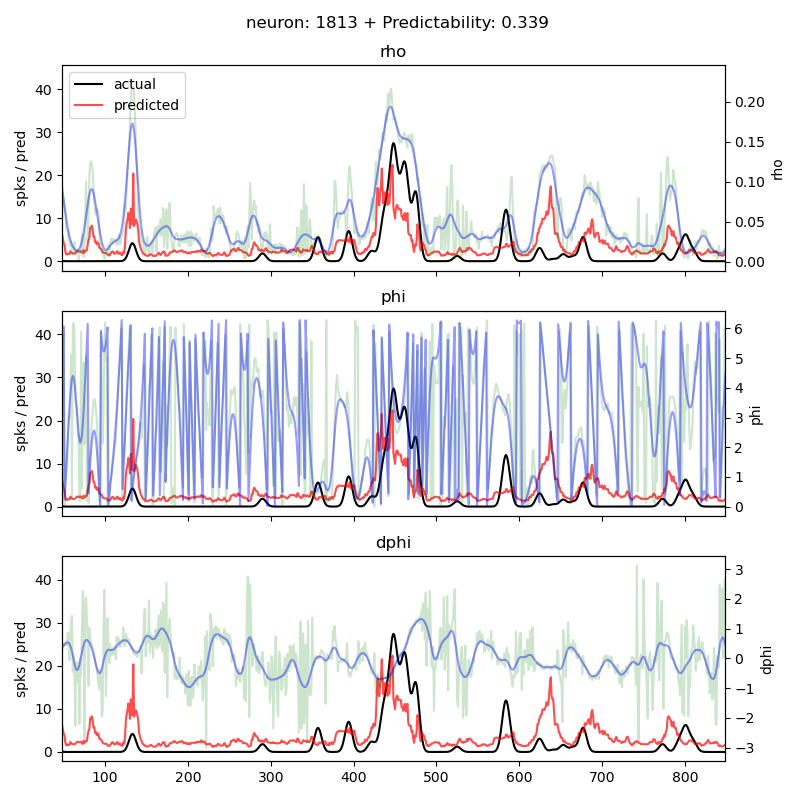

In [ ]:
# Plot fitting curves
testneuron=30
#testneuron=456
testneuron=1813

rho = rho_all[testneuron]
phi = phi_all[testneuron]
dphi = dphi_all[testneuron]
spks = spks_all[testneuron]

rho_train=rho[:train_split_index]
phi_train=phi[:train_split_index]
dphi_train=dphi[:train_split_index]
spks_train=spks[:train_split_index]

rho_test=rho[train_split_index:]
phi_test=phi[train_split_index:]
dphi_test=dphi[train_split_index:]
spks_test=spks[train_split_index:]
         
interpolator, Z, rho_centers, phi_centers, dphi_centers=fit_model(rho_train, phi_train, dphi_train, spks_train, hanning_window=hanning_window, smooth_stim_FWHM_samples=average_FWHM_samples)

pred_spks_test=apply_model(interpolator, rho_test, phi_test, dphi_test, smooth_stim_FWHM_samples=average_FWHM_samples)

plot_model(rho_test, phi_test, dphi_test, spks_test, pred_spks_test, title=f"neuron: {testneuron} + Predictability: {X_corr[testneuron]:.3f} ", smooth_stim_FWHM_samples=average_FWHM_samples)


In [38]:
df = pd.DataFrame({'respcorr': respcorr, 'max_values': X_corr})
df.to_csv(Path(data_path) / 'respcorr_max_values.csv', index=False)

In [ ]:
#save results into cell database
input_pickle_path= Path(data_path) / "cells_waven1.cellDB_pickle"
if input_pickle_path.exists():
    df_cells=pd.read_pickle(open(input_pickle_path,"rb"))
else:
    df_cells = pd.DataFrame()
    for _idx in range(n_neurons): #handling only good components
            record={}
            record['cell_id'] = _idx
            record['SeriesID'] = 'unknown'
            df_cells = pd.concat([df_cells, pd.DataFrame([record])], ignore_index=True)

df_cells = df_cells.set_index("cell_id", drop=False)

df_cells["tun_rho"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_phi"] = pd.Series([None] * len(df_cells), dtype="object")
df_cells["tun_dphi"] = pd.Series([None] * len(df_cells), dtype="object")


for _idx in tqdm(range(n_neurons)):
    df_cells.loc[_idx,'Predictability'] = X_corr[_idx]
    df_cells.loc[_idx,'Full_pred_corr'] = Full_corr[_idx]
    
    Z = Zs[_idx]
    tuning_rho=np.mean(Z, axis=(1,2))
    tuning_phi=np.mean(Z, axis=(0,2))
    tuning_dphi=np.mean(Z, axis=(1,2))
    
    df_cells.at[_idx, 'tun_rho'] = tuning_rho
    df_cells.at[_idx, 'tun_phi'] = tuning_phi
    df_cells.at[_idx, 'tun_dphi'] = tuning_dphi
    
    max_idx=np.unravel_index(np.argmax(Z), Z.shape)
    df_cells.loc[_idx, 'Rho'] = rho_centers[max_idx[0]]
    df_cells.loc[_idx, 'Phi'] = phi_centers[max_idx[1]]
    df_cells.loc[_idx, 'DPhi'] = dphi_centers[max_idx[2]]



picles_path=Path(data_path) / "cells_waven2.cellDB_pickle"
df_cells.to_pickle(picles_path)

# Saving cell database to xls file. Omitting complicated data
df_cells.drop(columns=['WL_transient_squared', 'WL_transient_phase', 'Activity_mean', 'contour', 'tun_xs', 'tun_ys', 'tun_angles', 'tun_sizes', 'tun_freqs', 'tun_rho', 'tun_phi', 'tun_dphi'], inplace=True, errors='ignore')
df_cells.to_excel(Path(data_path) / "cells_waven2.xlsx", index=False)

print(f"Saved cell database to {picles_path}")



100%|██████████| 2238/2238 [00:00<00:00, 5508.38it/s]


Saved cell database to D:\SynologyDriveSyncedDATA\PROCESSED\GBM\GBM11\g11_0508_full\ZEBRA_ANALYSIS\cells_waven2.cellDB_pickle


In [40]:
TODO
check for better performance:
        -t shift 3 -6 10 samples
        more freq, sizes
        
predictability score - on the last 2 trials - test/train split vs trials. -if trials>3

visualizations: cell plots - tuning curves
FOV plots - retinotopy, orientation tuning

        
parallel analysis on different seed videos

  ?? speed brute force-val?


SyntaxError: invalid syntax (1667171882.py, line 2)